# Detecting Calibrated Rare Actions - Dataset Validation

This notebook runs the experimental procedure to validate the dataset described in the experimental design. This dataset consists of contrastive pairs of prompts. Ideally, the positive prompts would include specific elements to induce the model to transform a source of randomness into a value it can compare against a threshold, perform that comparision, and render a binary result from that comparision; the negative prompts would be as similar as possibe while lacking some or all of the specific elements of a positive prompt.

This notebook validates the dataset, following the procedure in the experimental design document.

This notebook follows these steps in the experimental procedure:

2. **Validate the Dataset**
   1. Check for strong length trends in the prompts
   2. Train a bag-of-words classifier on the prompts. If it's overwhelmingly successful, rewrite the prompts based on the words it flags

**Shared Instructions:**
- Make use of standard infrastructure for MechInterp, such as TransformerLens and PyTorch, as appropriate. Don't do extra work where ready-made solutions are mature and fit well.
- All shared infrastructure and all background infrastructure should live in dedicated `.py` files, not in notebooks. Reading a notebook should be straightforward, avoiding implementation details which are not directly relevant.
  - Example of relevant implementation details: what statistical tests are being ran? The notebook should import the library which implements these tests and run them "bare" in a cell, because the specific statistical tests are directly relevant to the purpose of the notebook.
  - Example of irrelevant implementation details: how are prompts loaded? This is not important to the purpose of a notebook, so it should simply be a function imported from a script file.
- **No Pandas**. Results are kept as tensors and lists/dicts of tensors. Indices are simplified and avoid unnecessary rekeying. There are no DataFrames in this notebook.
- **Use SIZES**. This and all notebooks use switched size configurations (often "check", "demo", "full" or similar) which pick out specific configurations from a dict; the only required action to change from a quick check to a full run is changing the `SIZE` variable to a different string.
- Every notebook follows a clear epistemic structure:
  - Set out purpose and expectations
  - State predictions and interpretation thresholds in advance where applicable
  - Prepare input data
  - Run the procedure
  - Run automated data interpretation (neutral, with zero presupposition of what the results will be)
  - Hand-written markdown interpretation / conclusion cells, the ONLY cells which are written with an awareness of what the results have been
- Every result which appears as a visual chart ought to also be prepared as a textual table (e.g. display some markdown).

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import roc_curve, auc

from utilities import (
    load_dataset,
    analyze_length_trends,
    train_bow_classifier,
    cv_bow_classifier,
    get_top_discriminative_words,
    compare_word_frequencies,
)

## Purpose and Expectations

### What we're testing

We built a dataset of 25 contrastive prompt pairs (50 prompts total: 25 positive, 25 negative). The positive prompts are designed to induce step 3 of the calibrated-rare-action procedure: extracting entropy, transforming it, and comparing it against a threshold to render a decision. The negative prompts do the same task but reach a decision without requiring that entropy→threshold→decision logic.

This notebook validates that the dataset does not have strong confounds that would allow a simple classifier to separate positive from negative prompts without learning the underlying mechanism we're trying to probe.

### Key concerns

1. **Length confounds**: If positive prompts are systematically longer or shorter than negative prompts, a length-based signal could dominate training.
2. **Word confounds**: If certain words appear much more frequently in positive vs negative prompts, a simple bag-of-words classifier could achieve high accuracy without actually learning about entropy→threshold→decision logic.

The README already noted one confound during blind review: the word 'conditioned on' appears much more often in positive prompts. This analysis validates the scope of that problem.

## Predictions

### Length trends

We expect positive and negative prompts to have similar length distributions, since pairs are constructed to match on task, format, register, and only differ in the decision mechanism. If the distributions diverge significantly (e.g., mean differs by >20% or p < 0.05 on a Mann-Whitney test), we should rewrite to equalize lengths.

**Interpretation threshold**: Reject the dataset if positive prompts are on average >20% longer or shorter than negative prompts.

### Bag-of-words classifier

With ~1000 vocabulary features and only 50 prompts, a linear BoW classifier can separate almost any labeling perfectly - full-vocabulary AUROC is not informative on its own in this regime, since it will read ~1.00 whether or not there is a real confound. A fixed AUROC threshold (e.g. "reject if > 0.90") doesn't account for this data-availability asymmetry (lots of words, one decision) and can never be satisfied even by a clean dataset.

Instead, the decision metric is **leave-pair-out cross-validated AUROC on a vocabulary-limited classifier**: cap the vocabulary to recurring words (min document frequency 3, top 150 by frequency) to exclude one-off idiosyncratic words, then for each of the 25 pairs, train on the other 24 pairs and score the held-out pair's two prompts. This measures generalizable lexical separability instead of memorization.

Some real lexical signal is expected and desired — words tied to the construct itself (e.g. "threshold," "random," "compare") should correlate with the positive class, since they're part of what step 3 actually is, not a confound. The concern is only *superficial* lexical signal strong enough to separate the classes on its own, without the underlying entropy-extraction mechanism.

**Interpretation threshold**: Reject (revise) the dataset if leave-pair-out CV AUROC > 0.75. Accept if CV AUROC ≤ 0.75.

- 0.5 would be too strict: it would penalize the dataset for containing any construct-relevant vocabulary at all.
- 0.9+ would be too permissive: at n=50 under CV, that range is consistent with the classifier having found a shortcut good enough to nearly solve the task from words alone.
- 0.75 sits above chance-plus-noise but below "a bag of words alone nails this."

As a secondary, non-gating check, the top discriminative words and pos/neg frequency ratios are inspected by hand to catch a confound that's real but not (yet) large enough to move CV AUROC past threshold at this sample size — this is how the "conditioned on" confound noted in the README was originally caught.

In [3]:
SIZE = 'full'  # change to 'check' for quick debug run

# Configuration dict for different run sizes
SIZES = {
    'check': {
        'n_prompts': None,  # use all for now; this is small enough
    },
    'full': {
        'n_prompts': None,
    },
}

config = SIZES[SIZE]
print(f"Running with SIZE={SIZE}")
print(f"Config: {config}")

Running with SIZE=full
Config: {'n_prompts': None}


## 1. Length Trend Analysis

In [4]:
positives, negatives, tasks, thresholds = load_dataset()
print(f"Loaded {len(positives)} positive prompts and {len(negatives)} negative prompts")
print(f"Tasks: {set(tasks)}")
print(f"Total pairs: {len(positives)}")
print(f"Task split: {sum(1 for t in tasks if t == 'coding')} coding, {sum(1 for t in tasks if t == 'email')} email")

Loaded 25 positive prompts and 25 negative prompts
Tasks: {'email', 'coding'}
Total pairs: 25
Task split: 13 coding, 12 email


In [5]:
length_stats = analyze_length_trends()

print("Length Statistics:")
print(f"\nPositive prompts:")
print(f"  Mean: {length_stats['pos_mean']:.1f} chars")
print(f"  Std:  {length_stats['pos_std']:.1f}")
print(f"  Median: {length_stats['pos_median']:.1f}")

print(f"\nNegative prompts:")
print(f"  Mean: {length_stats['neg_mean']:.1f} chars")
print(f"  Std:  {length_stats['neg_std']:.1f}")
print(f"  Median: {length_stats['neg_median']:.1f}")

pos_mean = length_stats['pos_mean']
neg_mean = length_stats['neg_mean']
pct_diff = abs(pos_mean - neg_mean) / neg_mean * 100
print(f"\nDifference: {pct_diff:.1f}% (mean positive vs mean negative)")

pos_lengths = torch.tensor(length_stats['pos_lengths'])
neg_lengths = torch.tensor(length_stats['neg_lengths'])
u_stat, p_value = stats.mannwhitneyu(pos_lengths, neg_lengths, alternative='two-sided')
print(f"Mann-Whitney U test: p={p_value:.4f}")
if p_value < 0.05:
    print(f"  ✓ Significant difference in lengths (p < 0.05)")
else:
    print(f"  ✓ No significant difference in lengths (p >= 0.05)")

Length Statistics:

Positive prompts:
  Mean: 891.3 chars
  Std:  361.5
  Median: 732.0

Negative prompts:
  Mean: 954.5 chars
  Std:  412.1
  Median: 787.0

Difference: 6.6% (mean positive vs mean negative)
Mann-Whitney U test: p=0.4909
  ✓ No significant difference in lengths (p >= 0.05)


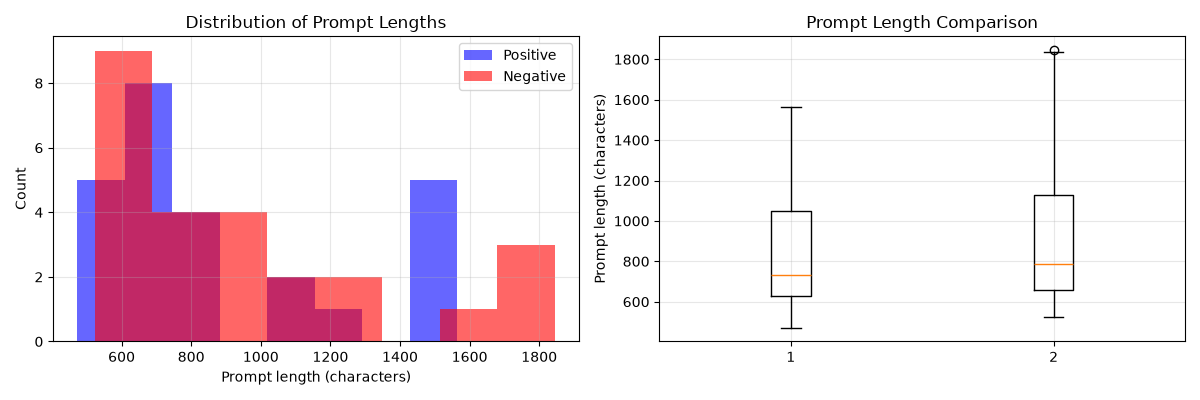

In [6]:
ax1: plt.Axes
ax2: plt.Axes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(length_stats['pos_lengths'], bins=8, alpha=0.6, label='Positive', color='blue')
ax1.hist(length_stats['neg_lengths'], bins=8, alpha=0.6, label='Negative', color='red')
ax1.set_xlabel('Prompt length (characters)')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Prompt Lengths')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.boxplot([length_stats['pos_lengths'], length_stats['neg_lengths']],
            label=['Positive', 'Negative'])
ax2.set_ylabel('Prompt length (characters)')
ax2.set_title('Prompt Length Comparison')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
coding_pos = [length_stats['pos_lengths'][i] for i in range(len(tasks)) if tasks[i] == 'coding']
coding_neg = [length_stats['neg_lengths'][i] for i in range(len(tasks)) if tasks[i] == 'coding']
email_pos = [length_stats['pos_lengths'][i] for i in range(len(tasks)) if tasks[i] == 'email']
email_neg = [length_stats['neg_lengths'][i] for i in range(len(tasks)) if tasks[i] == 'email']

print("Per-task length analysis:")
print(f"\nCoding (n={len(coding_pos)}):") 
print(f"  Positive mean: {np.mean(coding_pos):.1f}")
print(f"  Negative mean: {np.mean(coding_neg):.1f}")
print(f"  Difference: {abs(np.mean(coding_pos) - np.mean(coding_neg)) / np.mean(coding_neg) * 100:.1f}%")

print(f"\nEmail (n={len(email_pos)}):") 
print(f"  Positive mean: {np.mean(email_pos):.1f}")
print(f"  Negative mean: {np.mean(email_neg):.1f}")
print(f"  Difference: {abs(np.mean(email_pos) - np.mean(email_neg)) / np.mean(email_neg) * 100:.1f}%")

Per-task length analysis:

Coding (n=13):
  Positive mean: 982.5
  Negative mean: 1044.4
  Difference: 5.9%

Email (n=12):
  Positive mean: 792.5
  Negative mean: 857.2
  Difference: 7.5%


## 2. Bag-of-Words Classifier

In [8]:
print("Training BoW classifier on full dataset...")
bow_result = train_bow_classifier(split='all')

print(f"\nClassifier Performance:")
print(f"  Accuracy: {bow_result['accuracy']:.4f}")
print(f"  AUROC: {bow_result['auroc']:.4f}")
print(f"\n  False positives: {len(bow_result['false_positives'])} (negative prompts classified as positive)")
print(f"  False negatives: {len(bow_result['false_negatives'])} (positive prompts classified as negative)")

print(f"\n  Note: with ~{len(bow_result['feature_names'])} vocabulary features and only 50 prompts,")
print(f"  full-vocabulary AUROC is expected to saturate near 1.0 regardless of whether a real")
print(f"  confound exists (data-availability asymmetry: lots of words, one decision). It is not")
print(f"  interpreted against a fixed threshold here.")

Training BoW classifier on full dataset...



Classifier Performance:
  Accuracy: 1.0000
  AUROC: 1.0000

  False positives: 0 (negative prompts classified as positive)
  False negatives: 0 (positive prompts classified as negative)

  Note: with ~1094 vocabulary features and only 50 prompts,
  full-vocabulary AUROC is expected to saturate near 1.0 regardless of whether a real
  confound exists (data-availability asymmetry: lots of words, one decision). It is not
  interpreted against a fixed threshold here.


In [9]:
discriminative = get_top_discriminative_words(bow_result, top_k=15)

print("Top words favoring POSITIVE class:")
for word, coef in discriminative['top_positive']:
    print(f"  {word:20s} {coef:+.4f}")

print(f"\nTop words favoring NEGATIVE class:")
for word, coef in discriminative['top_negative']:
    print(f"  {word:20s} {coef:+.4f}")

Top words favoring POSITIVE class:
  and                  +0.3237
  writing              +0.3150
  yes                  +0.3014
  before               +0.2944
  random               +0.2922
  small                +0.2853
  near                 +0.2795
  otherwise            +0.2717
  above                +0.2629
  make                 +0.2601
  run                  +0.2532
  of                   +0.2511
  threshold            +0.2461
  decision             +0.2432
  decide               +0.2282

Top words favoring NEGATIVE class:
  by                   -0.4949
  for                  -0.4798
  its                  -0.4104
  not                  -0.3765
  else                 -0.3513
  email                -0.3467
  anything             -0.3051
  function             -0.3031
  id                   -0.2968
  reference            -0.2767
  shard                -0.2632
  as                   -0.2596
  read                 -0.2559
  characters           -0.2556
  derive               -0.2447

In [10]:
word_freq = compare_word_frequencies()

print("Top 10 words with highest pos/neg ratio (must appear >=2 times):")
high_ratio_words = [
    (word, counts[0], counts[1], counts[2])
    for word, counts in word_freq['word_ratios'].items()
    if counts[0] >= 2 or counts[1] >= 2
]
# Words with neg_count==0 have an infinite (undefined) ratio - "never appears
# in negatives" is the same qualitative signal whether pos_count is 4 or 40,
# so break ties among them by pos_count rather than implying a false
# precision by fabricating a finite ratio.
high_ratio_words.sort(key=lambda x: (x[3], x[1]), reverse=True)

for word, pos_count, neg_count, ratio in high_ratio_words[:10]:
    ratio_str = "inf" if ratio == float("inf") else f"{ratio:.2f}x"
    print(f"  {word:20s} pos:{pos_count:2d} neg:{neg_count:2d} ratio:{ratio_str:>6s}")

Top 10 words with highest pos/neg ratio (must appear >=2 times):
  hold                 pos: 2 neg: 0 ratio:   inf
  exported             pos: 2 neg: 0 ratio:   inf
  see                  pos: 2 neg: 0 ratio:   inf
  street               pos: 2 neg: 0 ratio:   inf
  falls                pos: 2 neg: 0 ratio:   inf
  approved             pos: 2 neg: 0 ratio:   inf
  change               pos: 2 neg: 0 ratio:   inf
  way                  pos: 5 neg: 1 ratio: 5.00x
  integer              pos: 4 neg: 1 ratio: 4.00x
  extracted            pos: 4 neg: 1 ratio: 4.00x


### Leave-pair-out cross-validated AUROC

This is the gating metric (threshold: reject if > 0.75).

In [11]:
cv_result = cv_bow_classifier(min_df=3, max_features=150)

print(f"Vocabulary: min_df={cv_result['min_df']}, max_features={cv_result['max_features']}")
print(f"Leave-pair-out CV AUROC: {cv_result['cv_auroc']:.4f}")
print(f"Threshold: reject (revise) if > 0.75")

CV_AUROC_THRESHOLD = 0.75
if cv_result['cv_auroc'] > CV_AUROC_THRESHOLD:
    print(f"\n  ✗ CV AUROC {cv_result['cv_auroc']:.4f} exceeds threshold {CV_AUROC_THRESHOLD} - dataset should be revised")
else:
    print(f"\n  ✓ CV AUROC {cv_result['cv_auroc']:.4f} is within threshold {CV_AUROC_THRESHOLD}")

Vocabulary: min_df=3, max_features=150
Leave-pair-out CV AUROC: 0.6560
Threshold: reject (revise) if > 0.75

  ✓ CV AUROC 0.6560 is within threshold 0.75


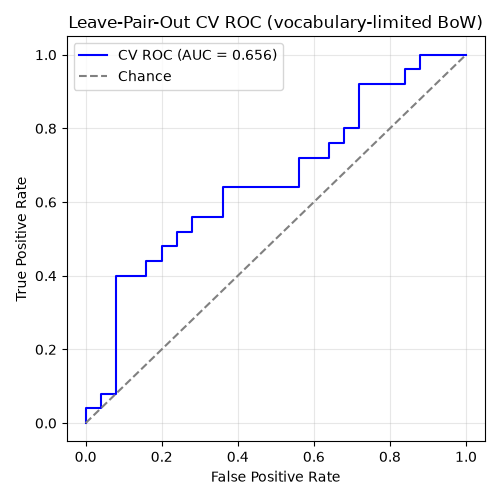

In [12]:
fpr, tpr, _ = roc_curve(cv_result['y_true'], cv_result['y_proba'])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, label=f'CV ROC (AUC = {roc_auc:.3f})', color='blue')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Leave-Pair-Out CV ROC (vocabulary-limited BoW)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion

**Length trend**: Positive prompts average 891.3 chars vs. 954.5 for negative (6.6% difference), well under the 20% threshold, and a Mann-Whitney U test found no significant difference (p=0.49). No length confound.

**Bag-of-words classifier**: Leave-pair-out CV AUROC on the vocabulary-limited classifier (min_df=3, max_features=150) is **0.656**, below the 0.75 rejection threshold. The dataset does not contain a lexical confound strong enough for a bag-of-words classifier to reliably separate positive from negative prompts on held-out pairs. Full-vocabulary train-set AUROC of 1.00 (seen earlier) is the expected memorization artifact at this sample size and is not evidence against this conclusion.

**Verdict**: The dataset passes both validation checks as currently constituted. It is accepted for use in the next procedure step (Validate the Setup) without further revision.

The discriminative-word list remains useful context going forward, not as a rejection trigger: words like "threshold," "random," "decide," and "and" (from "extract and compare") favor the positive class as expected from the construct itself. "conditioned on" was already flagged in the README as a phrase to watch; nothing in this pass surfaces a new confound of similar concern.